sources:

https://medium.com/data-science-collective/python-visualization-tools-to-level-up-from-matplotlib-0b0fa7fe1f81

Gemini :)

https://blog.tidy-intelligence.com/posts/ggplot2-vs-plotnine/

https://github.com/erikgahner/awesome-ggplot2/blob/master/README.md

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine, load_iris

# Agenda:

- Matplotlib
- Seaborn
- PlotNine
- YellowBrick
- Geoplot

# Setup df's

In [2]:
wine = load_wine()
wine_df = pd.DataFrame(data=wine.data, columns = wine.feature_names)
wine_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [3]:
print(wine.target_names)
print(wine.target)

['class_0' 'class_1' 'class_2']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [4]:
#setupclasses for wine_y (change from 1 to class_1)
wine_X = wine_df.copy()
wine_y = [wine.target_names[i] for i in wine.target]
# print(wine_y)
# print(wine_df['region'])
print(wine_df.columns)

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='str')


In [5]:
#do the same for wine_df as for wine_y
wine_df['region'] = [wine.target_names[i] for i in wine.target]
# print(wine_df['region'])

In [6]:
iris = load_iris()
iris_df = pd.DataFrame(data = iris.data, columns = iris.feature_names)
iris_df['species'] = [iris.target_names[i] for i in iris.target]

# MatplotLib

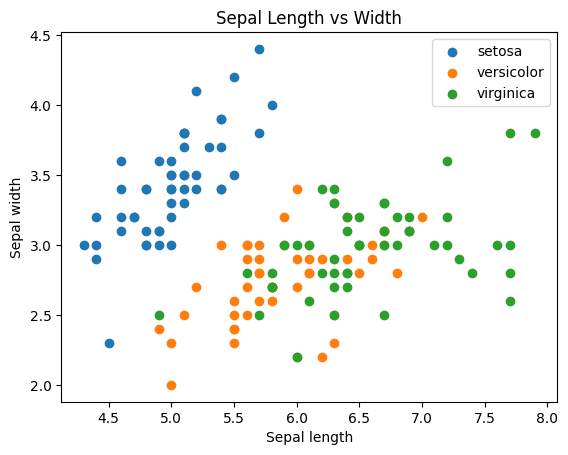

In [7]:
X = iris.data
y = iris.target

plt.figure()
for i, label in enumerate(iris.target_names):
    plt.scatter(X[y == i, 0], X[y == i, 1], label=label)

plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("Sepal Length vs Width")
plt.legend()
plt.show()

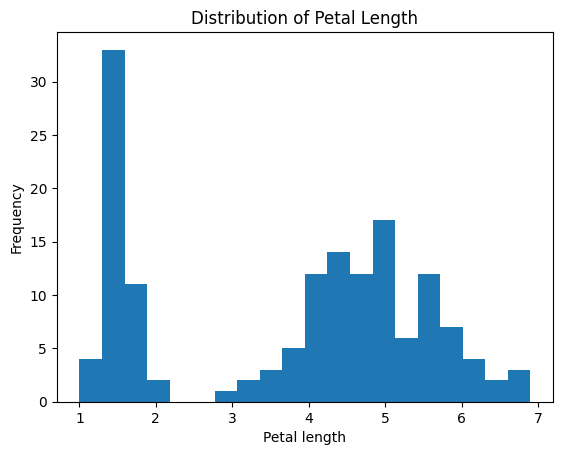

In [8]:
plt.figure()
plt.hist(X[:, 2], bins=20)  # petal length
plt.xlabel("Petal length")
plt.ylabel("Frequency")
plt.title("Distribution of Petal Length")
plt.show()

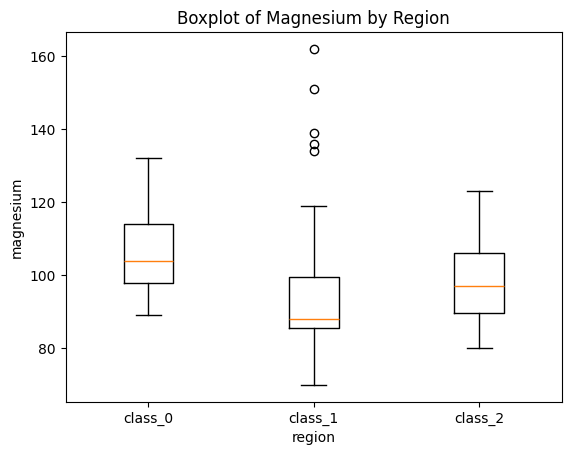

In [9]:
plt.figure()

regions = wine_df['region'].unique()
data = [wine_df[wine_df['region'] == r]['magnesium'] for r in regions]

plt.boxplot(data, tick_labels=regions)

plt.xlabel('region')
plt.ylabel('magnesium')
plt.title('Boxplot of Magnesium by Region')

plt.show()

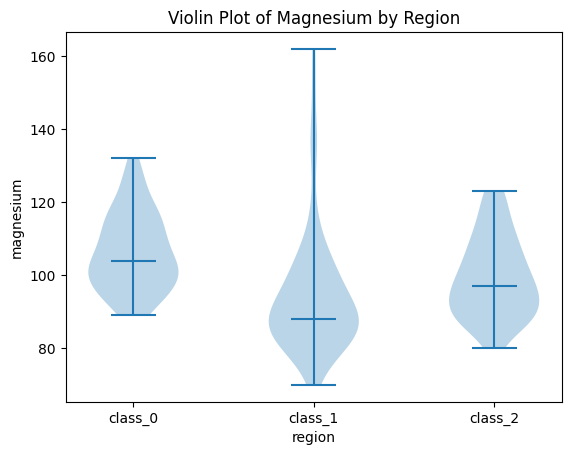

In [10]:
plt.figure()

plt.violinplot(data, showmeans=False, showmedians=True)

plt.xticks(range(1, len(regions) + 1), regions)

plt.xlabel('region')
plt.ylabel('magnesium')
plt.title('Violin Plot of Magnesium by Region')

plt.show()

# SEABORN

- a nicer alternative to matplotlib
- oriented torwards pd DataFrames
- similar plot types groupped (ex. catplot can be of kind box, swarm, bar)

In [11]:
import seaborn as sns

<Axes: xlabel='region', ylabel='magnesium'>

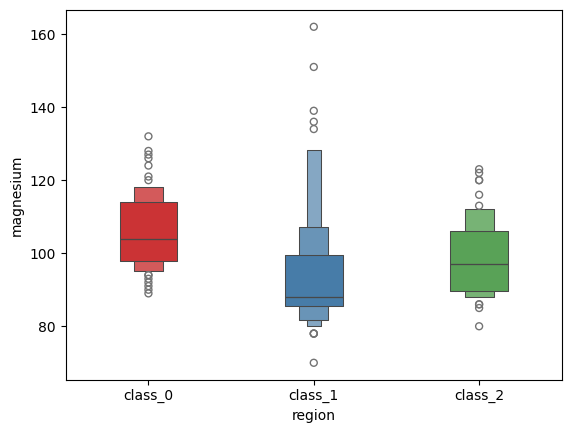

In [12]:
sns.boxenplot(wine_df, x = "region", y = "magnesium", hue="region", palette = 'Set1', legend= False, width = 0.35)


<Axes: xlabel='region', ylabel='magnesium'>

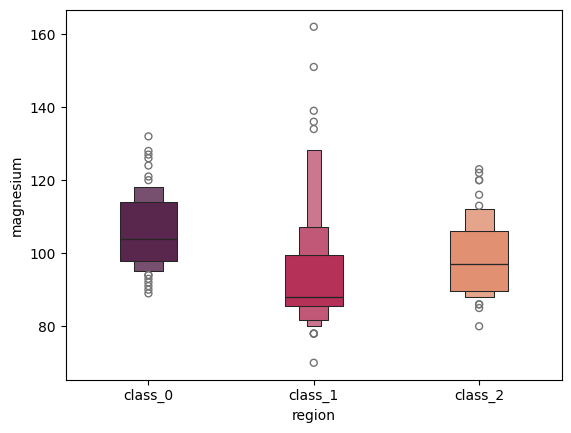

In [13]:
sns.boxenplot(wine_df, x = "region", y = "magnesium", hue="region", palette = 'rocket', legend= False, width = 0.35)


<Axes: xlabel='time', ylabel='observation'>

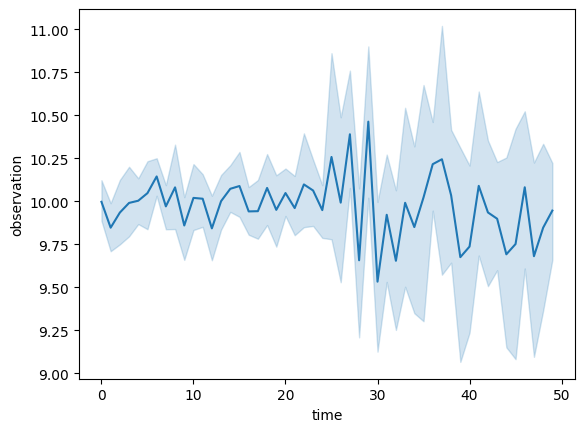

In [ ]:
my_time_series_data = pd.DataFrame({
    'time': np.repeat(range(50), 10),
    'group': np.tile(['a','b','c','d','e','f','g','h','i','j'], 50),
    'observation': np.hstack([np.random.normal(10, scale=0.3, size=250),
                              np.random.normal(10, scale=0.8, size=250)])
})
#errorbar='ci' => what type of uncertainty is shown, ci => confidence interval, sd => standard deviation,
#pi => prediction interval, se => standard error, None => no error bars


sns.lineplot(my_time_series_data, x='time', y='observation', errorbar='ci')


<Axes: xlabel='time', ylabel='observation'>

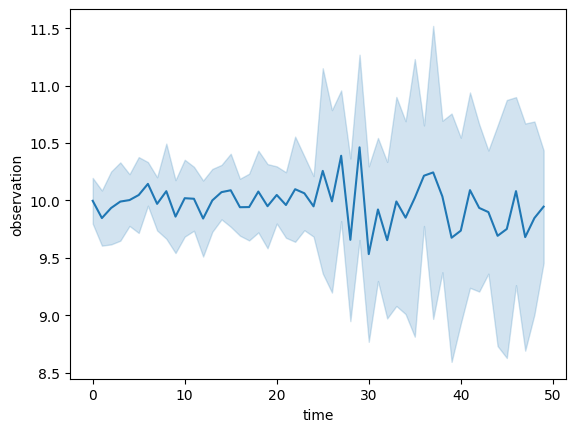

In [15]:
sns.lineplot(my_time_series_data, x='time', y='observation', errorbar='sd')


Nice way to change figures using kind

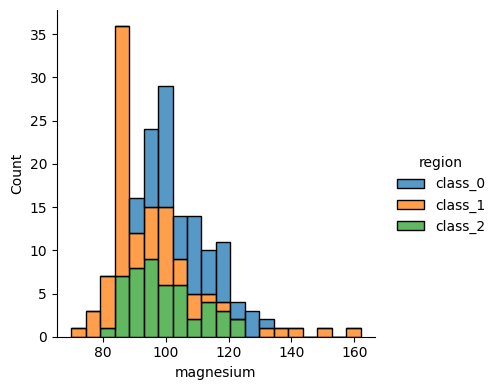

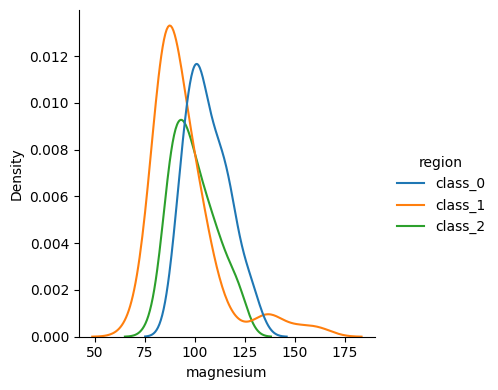

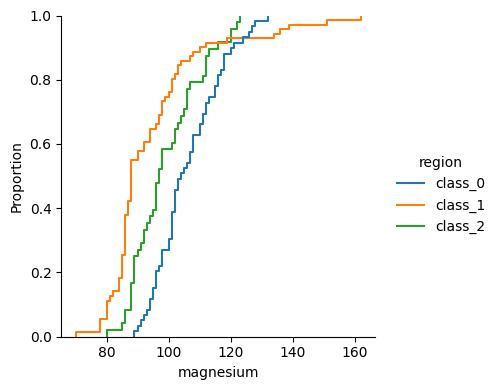

In [16]:
sns.displot(data=wine_df, x='magnesium', hue='region', legend=True, kind='hist', bins=20, multiple='stack', height=4)
sns.displot(data=wine_df, x='magnesium', hue='region', legend=True, kind='kde', height=4)
sns.displot(data=wine_df, x='magnesium', hue='region', legend=True, kind='ecdf', height=4)

HexBin as another nice option 
joinplot shows relatinship between two plots (here we have the random prediction to the actual value)

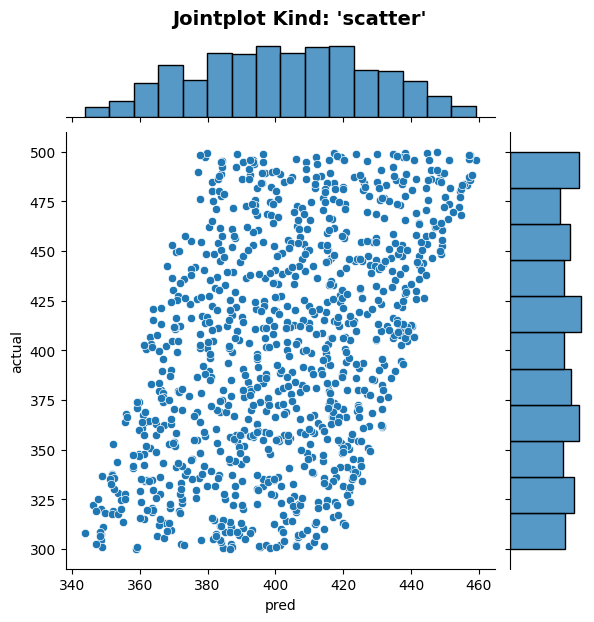

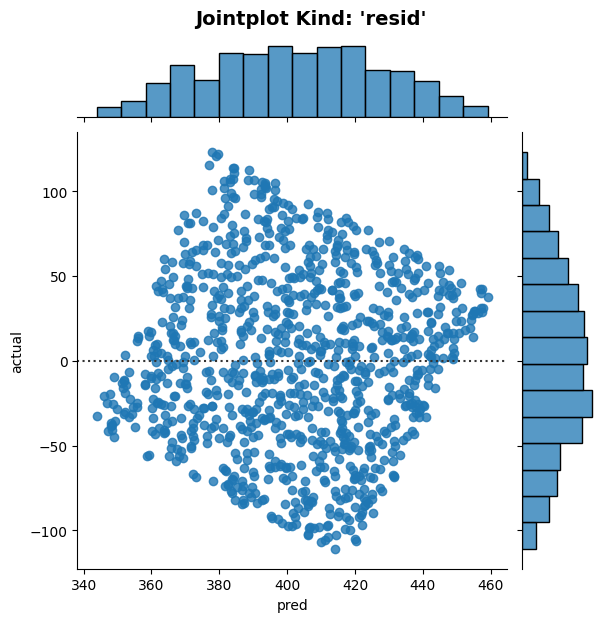

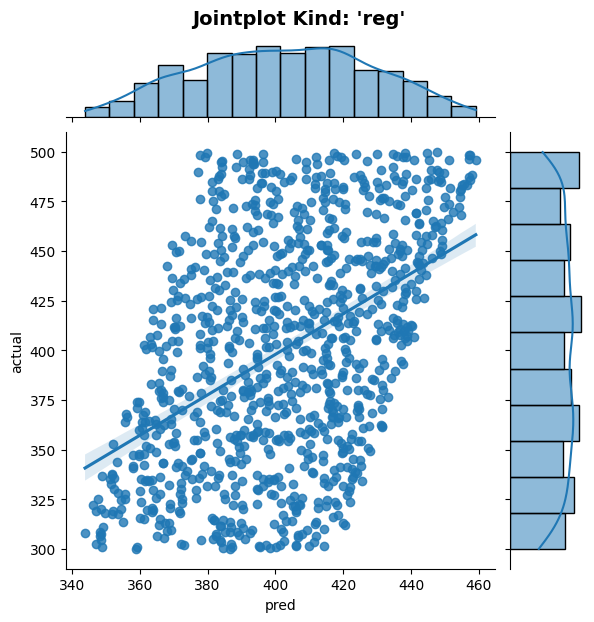

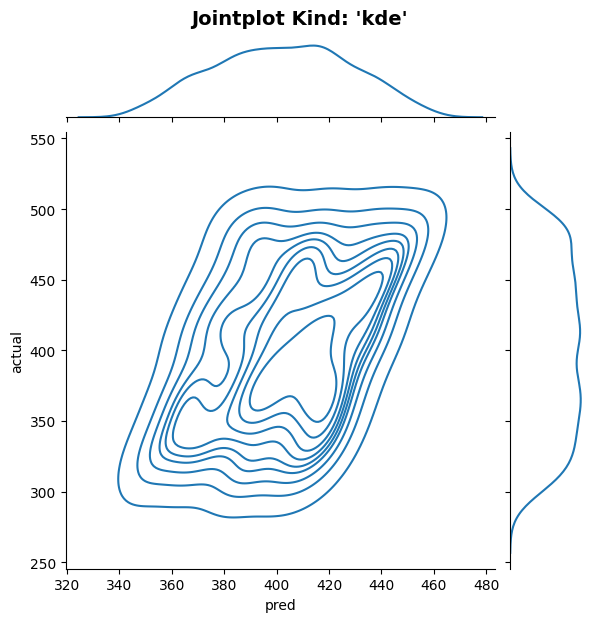

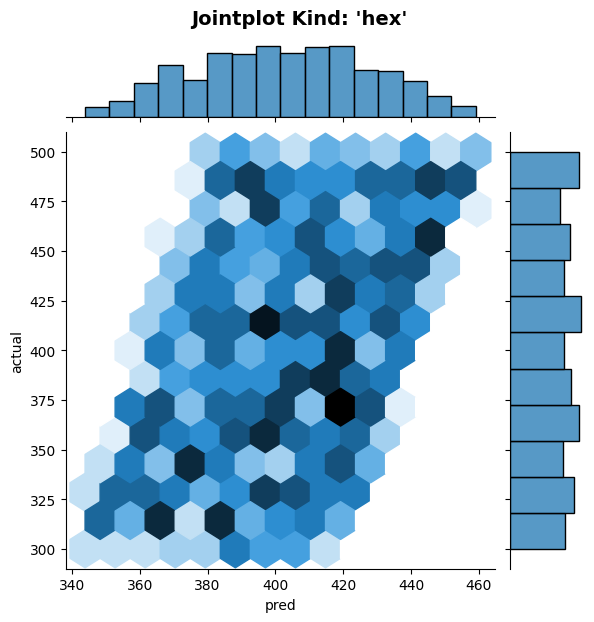

In [17]:
model_pred_data = (
    pd.DataFrame({'actual': np.random.random(size=1000)*200 + 300})
    .assign(pred=lambda df: (df.actual-0.8*(df.actual-400)) * np.random.uniform(low=0.9, high=1.1, size=1000))
)

# sns.jointplot(data=model_pred_data, x='pred', y='actual', kind='scatter')
# sns.jointplot(data=model_pred_data, x='pred', y='actual', kind='resid')
# sns.jointplot(data=model_pred_data, x='pred', y='actual', kind='reg')
# sns.jointplot(data=model_pred_data, x='pred', y='actual', kind='kde')
# sns.jointplot(data=model_pred_data, x='pred', y='actual', kind='hex')

# 2. Define the plot types
kinds = ['scatter', 'resid', 'reg', 'kde', 'hex']

for k in kinds:
    g = sns.jointplot(data=model_pred_data, x='pred', y='actual', kind=k)
    
    g.fig.suptitle(f"Jointplot Kind: '{k}'", y=1.03, fontsize=14, fontweight='bold')
    
    plt.show()

# PlotNine

- python version of ggplot2
- shares the "grammar of graphics" syntax
- more advnaced, but u can achive more

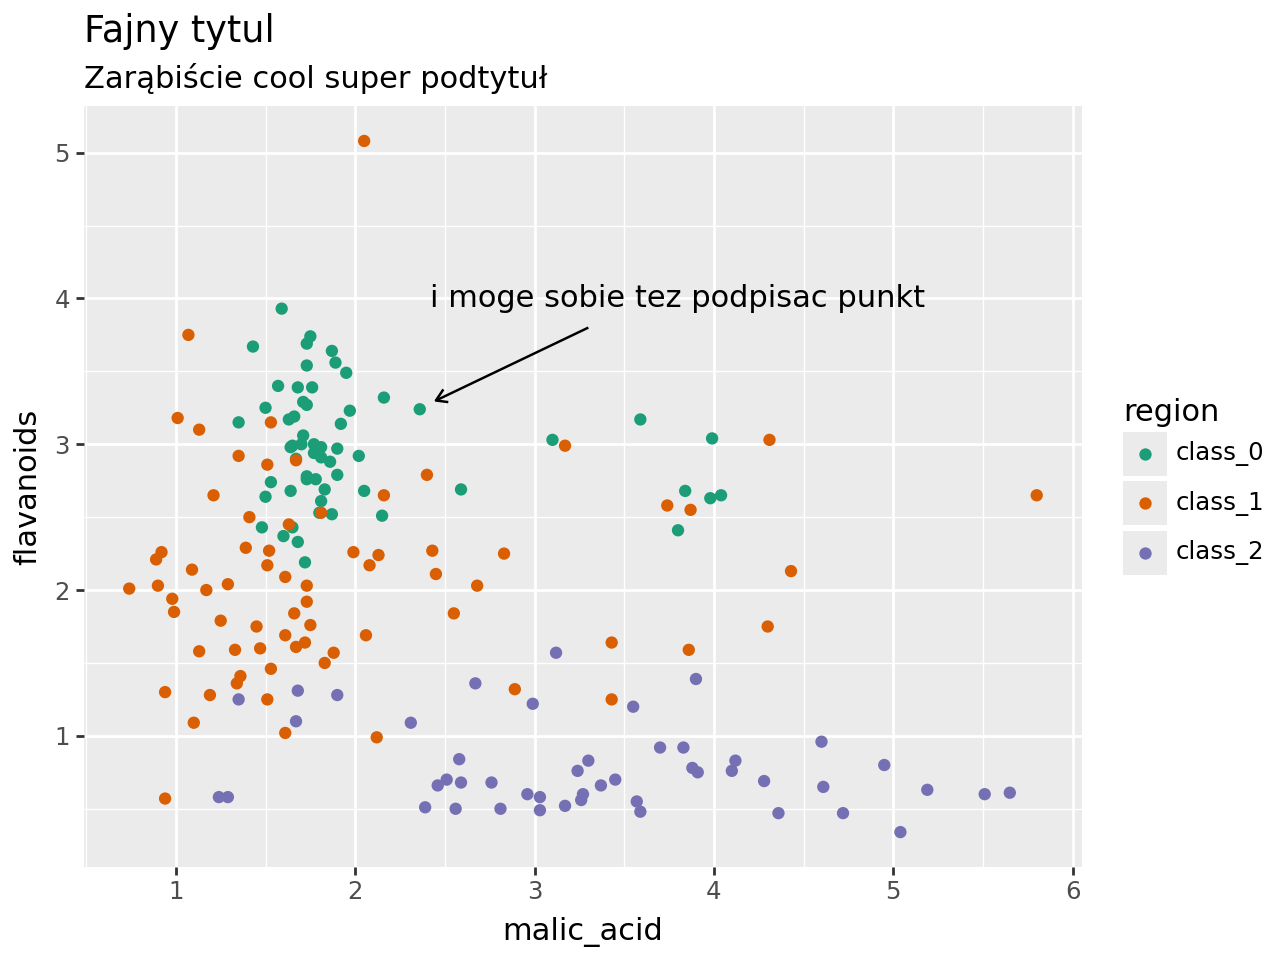

In [ ]:
from plotnine import (
    ggplot, aes,
    geom_point, geom_smooth, geom_boxplot, stat_count,
    arrow, annotate, position_dodge2,
    scale_color_brewer, scale_fill_brewer,
    guides, labs, theme, theme_minimal, theme_seaborn
)

(
    ggplot(wine_df, aes('malic_acid', 'flavanoids', colour='region'))
    + geom_point()
    # + geom_smooth(method='lm', se=False, fullrange=True, linetype='dashed', size=0.5)
    + scale_color_brewer(type='qualitative', palette='Dark2')
    + labs(title='Fajny tytul', subtitle='Zarąbiście cool super podtytuł')
    + annotate(geom='text', x=3.8, y=4, label='i moge sobie tez podpisac punkt')
    + annotate(geom='path', x=[3.3, 2.45], y=[3.8, 3.3], arrow=arrow(length=0.1))
)

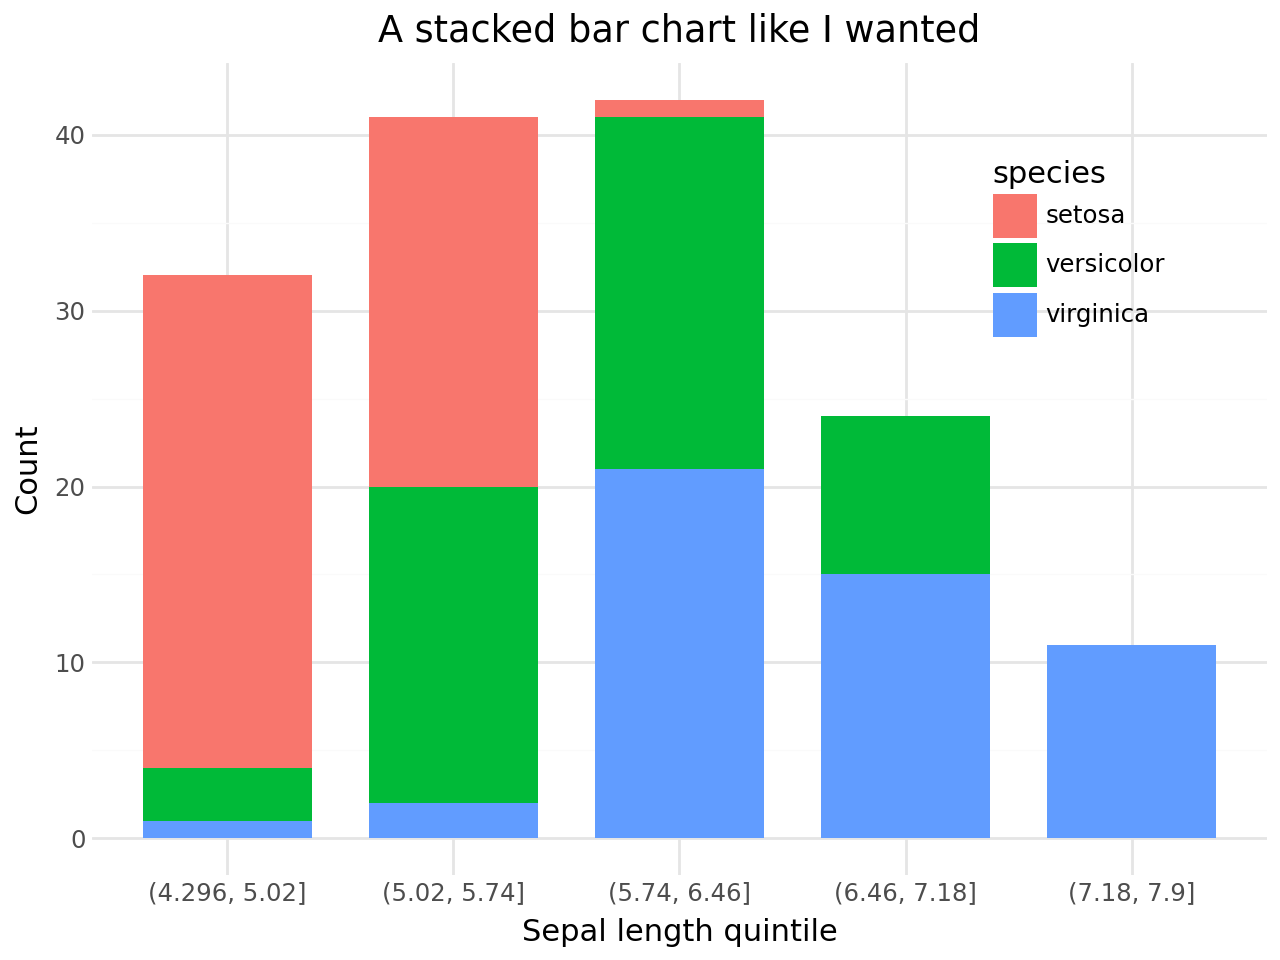

In [32]:
(
    ggplot(
        iris_df
        .assign(sepal_length_group = lambda df: pd.cut(df['sepal length (cm)'], 5))
    )
    + stat_count(aes(x='sepal_length_group', fill='species'), width=0.75)
    + theme_minimal()
    + labs(x='Sepal length quintile', y='Count', title='A stacked bar chart like I wanted')
    + theme(legend_position=(0.9, 0.85))
)

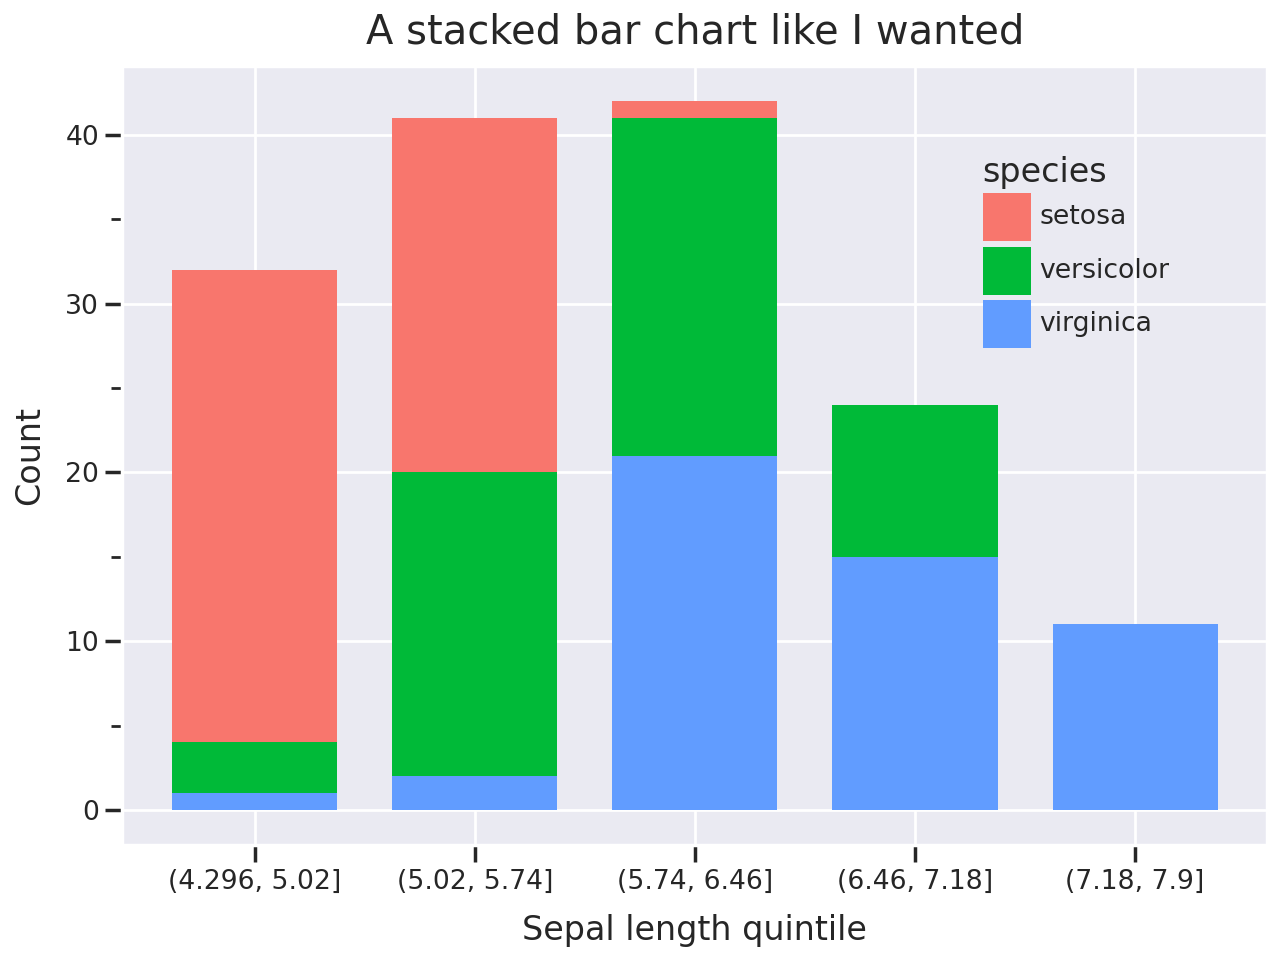

In [20]:
(
    ggplot(
        iris_df
        .assign(sepal_length_group = lambda df: pd.cut(df['sepal length (cm)'], 5))
    )
    + stat_count(aes(x='sepal_length_group', fill='species'), width=0.75)
    + theme_seaborn()
    + labs(x='Sepal length quintile', y='Count', title='A stacked bar chart like I wanted')
    + theme(legend_position=(0.9, 0.85))
)

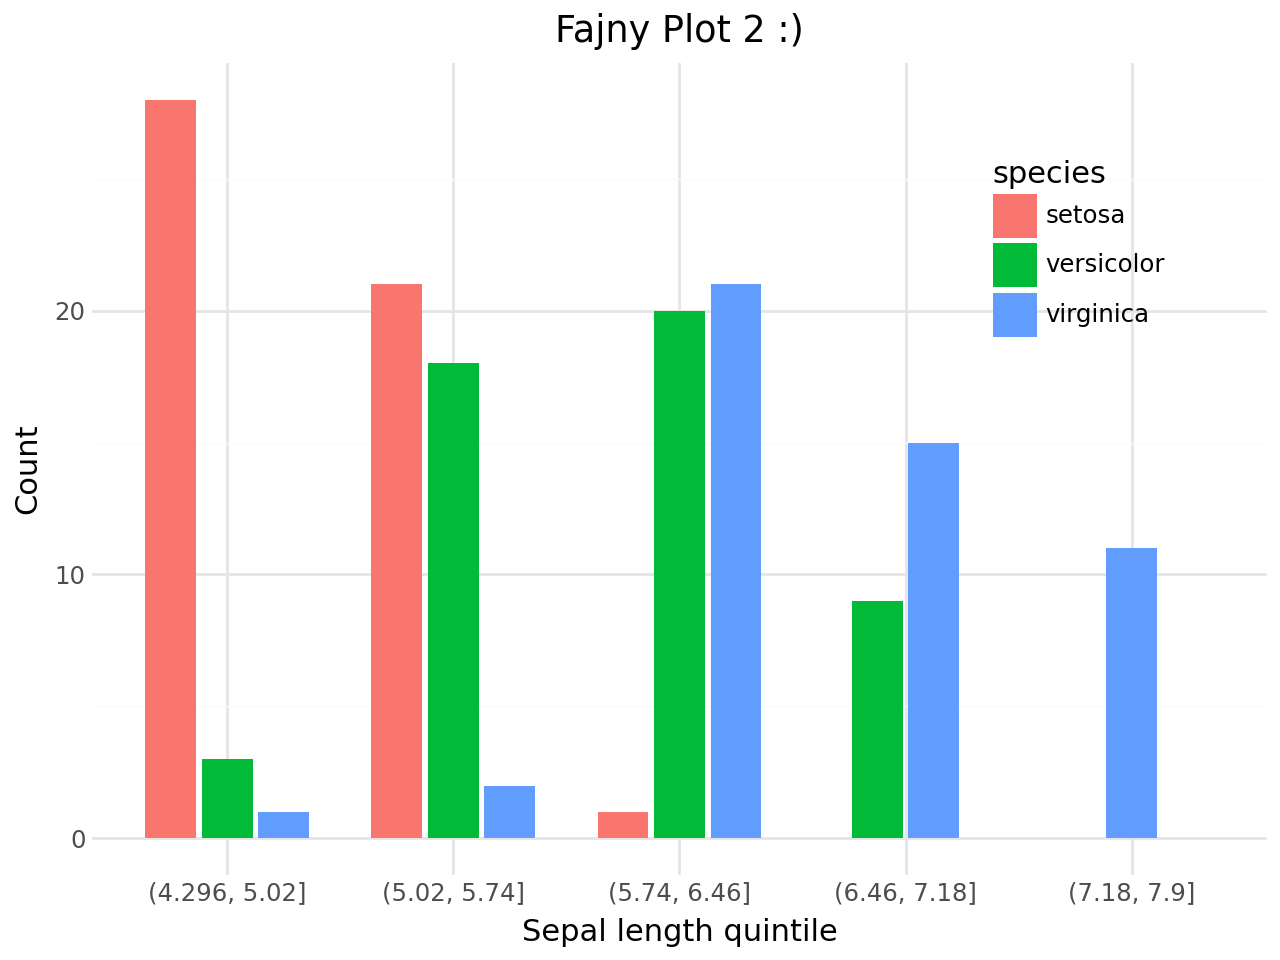

In [21]:
(
    ggplot(
        iris_df
        .assign(sepal_length_group = lambda df: pd.cut(df['sepal length (cm)'], 5))
    )
    + stat_count(aes(x='sepal_length_group', fill='species'), position=position_dodge2(preserve='single'), width=0.75)
    + theme_minimal()
    + labs(x='Sepal length quintile', y='Count', title='Fajny Plot 2 :)')
    + theme(legend_position=(0.9, 0.85))
)

# YellowBrick

- for AI vizualizations (predictions)

,estimator,RandomForestClassifier()
,ax,<Axes: >
,labels,None
,relative,True
,absolute,False
,xlabel,None
,stack,False
,colors,None
,colormap,None
,is_fitted,'auto'
,topn,None


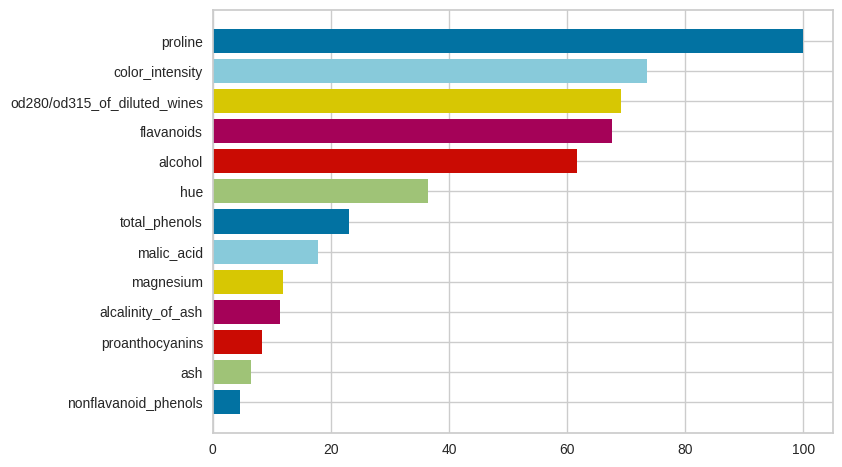

In [36]:
from yellowbrick.model_selection import FeatureImportances
from sklearn.ensemble import RandomForestClassifier

viz = FeatureImportances(RandomForestClassifier(n_estimators=100), relative=True)
viz.fit(wine_X, wine_y)

KNeighborsClassifier()


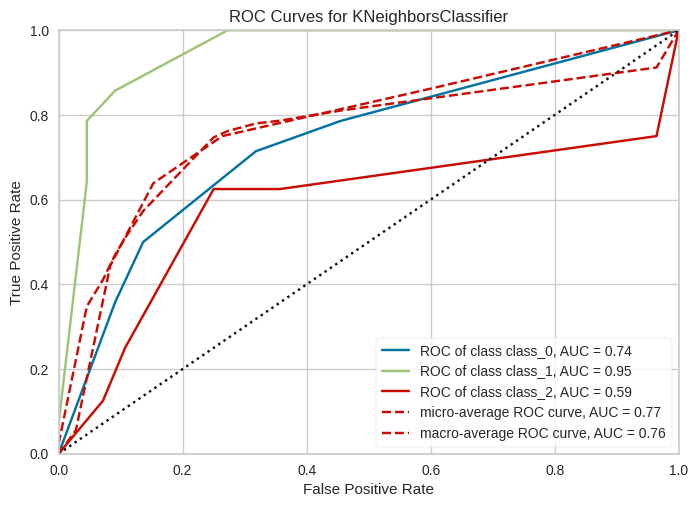

<Axes: title={'center': 'ROC Curves for KNeighborsClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from yellowbrick.classifier import ROCAUC
from sklearn.datasets import load_wine

data = load_wine()
X = data.data[:, [0, 2, 4]] #Alcohol, Ash, Magnesium
# X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)
print(knn)
knn._estimator_type = "classifier"
visualizer = ROCAUC(knn, classes=data.target_names)

visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)      
visualizer.show()                     

# GEOPLOT

- high level wrapper for matplotlib that using a extended
 version of pandas (geopandas, that holds shapes like polygons and points) helps us vizualize geospacial info

<class 'geopandas.geodataframe.GeoDataFrame'>
Index(['id', 'nazwa', 'geometry'], dtype='str')
    id                nazwa                                           geometry
0    1              śląskie  POLYGON ((19.4698 50.9154, 19.4628 50.91, 19.4...
1    2             opolskie  POLYGON ((17.8122 51.1349, 17.8234 51.118, 17....
2    3        wielkopolskie  POLYGON ((16.8487 53.6287, 16.8537 53.6387, 16...
3    4   zachodniopomorskie  POLYGON ((16.3716 54.4414, 16.3946 54.4477, 16...
4    5       świętokrzyskie  POLYGON ((19.7471 50.866, 19.7739 50.8777, 19....
5    6   kujawsko-pomorskie  POLYGON ((18.6768 53.6907, 18.6879 53.6991, 18...
6    7            podlaskie  POLYGON ((21.926 53.0781, 21.9141 53.0697, 21....
7    8         dolnośląskie  POLYGON ((16.4162 51.7849, 16.4492 51.788, 16....
8    9         podkarpackie  POLYGON ((22.5437 50.3563, 22.5493 50.3572, 22...
9   10          małopolskie  POLYGON ((20.5632 50.1997, 20.5724 50.1866, 20...
10  11            pomorskie  POLYGON 

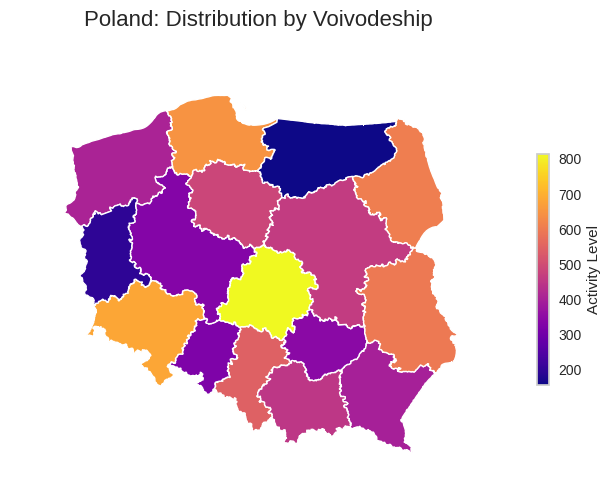

In [7]:
import geopandas as gpd
import geoplot as gplt
import geoplot.crs as gcrs #coordinate reference systems
import matplotlib.pyplot as plt
import numpy as np

url = "https://raw.githubusercontent.com/ppatrzyk/polska-geojson/master/wojewodztwa/wojewodztwa-min.geojson"
poland_gdf = gpd.read_file(url)
print(type(poland_gdf))
print(poland_gdf.columns)
print(poland_gdf)
poland_gdf['random_var'] = np.random.randint(100, 1000, len(poland_gdf))

ax = gplt.choropleth(
    poland_gdf,
    projection=gcrs.AlbersEqualArea(central_longitude=19, central_latitude=52), #center of poland
    hue='random_var',
    cmap='plasma',
    linewidth=1,
    edgecolor='white',
    legend=True,
    legend_kwargs={'location': 'right', 'label': 'Activity Level', 'shrink': 0.5}
)

plt.title('Poland: Distribution by Voivodeship', fontsize=16, pad=20)
plt.show()